In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import NMF
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import ward, dendrogram, fcluster, linkage, cophenet
from scipy.spatial.distance import pdist
from sklearn.preprocessing import normalize
from scipy.sparse import csr_matrix
from nltk.stem import SnowballStemmer
import nltk

import random

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/chlohal/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [17]:
df = pd.read_csv("./coronavirus_dataset_2000-2025.csv")

df.head()

,Unnamed: 0,identifier,doi,publication_year,journal,title,abstract,keywords
0,0,754107200001,10.1080/14639947.2022.2029212,2020,CONTEMP BUDDHISM,"buddhist ""solutions"" and action in the context...",this paper aims to understand the complex and ...,buddhism|covid-19|meditation|lockdown|adaptations
1,1,753006200001,10.1080/21528586.2021.2015624,2020,S AFR REV SOCIOL,homelessness and community based healthcare: a...,this article serves to describe health encount...,community-oriented primary care|street homeles...
2,2,747573400001,10.1080/21528586.2021.2018036,2020,S AFR REV SOCIOL,"fostering integrated, collaborative approaches...",this article maps the covid-19 pandemic and lo...,homelessness|shelters|city of tshwane|collabor...
3,3,652478200009,NaN,2020,CONSERV SCI CULT HER,"environment, food, culture: covid-19",human activities and the exploitation of natur...,covid-19|philosophy of insecurity|culture
4,4,561521500001,10.1080/22221751.2020.1803146,2020,EMERG MICROBES INFEC,"the ongoing covid-19 epidemic in minas gerais,...",the recent emergence of a coronavirus (sars-co...,sars-cov-2|genomic surveillance|minas gerais|s...


I'm going to toss in a vectorizer with no stopwords to start out, and see what the most common terms are.

In [25]:
vectorizer = CountVectorizer(strip_accents='ascii',
                             encoding='ascii',
                             decode_error='ignore',
                             lowercase=True,
                             analyzer="word")
term_mat = vectorizer.fit_transform((df['abstract'] + " " + df['keywords'] + " " + df['title']).dropna())

In [26]:
counts = term_mat.sum(axis=0).A[0]
words = vectorizer.get_feature_names_out()

In [27]:
word_count_df = pd.DataFrame(dict({"counts": counts, "words": words}))
word_count_df.sort_values("counts", ascending=False, inplace=True)

In [28]:
word_count_df.head(n=30)

,counts,words
234436,3563224,the
170854,2498892,of
29132,2468930,and
122441,1607957,in
237464,1393893,to
66823,1232630,covid
4922,1223638,19
254335,757669,with
99303,585942,for
253377,531226,were


Okay, that exploration didn't bear much fruit. Words that are intuitively important, like "patients" or "covid", are more common than words like "or", which is intuitively not important. We shouldn't use a simple stopword commonality cutoff.

We'll use another library for some smart stemming and stopwords

Instead of `TfidfTransformer`, use `TfidfVectorizer` for efficiency.

In [37]:
stemmer = SnowballStemmer("english", ignore_stopwords=True)
# Ensure that the vectorizer uses the same list of stopwords as the stemmer.
# This is important because otherwise, the stemmer might stem stopwords on the vectorizer's list,
# which would result in stopwords getting through the remover.
stop_words = list(stemmer.stopwords)

# Vectorizer that uses the stemmer's stripping and stopwords.
# It also restricts words to _only_ alphabetical strings, discarding common
# issues like confidence intervals, numbers, etc. Numbers may be important, but 
# for analysis like this (per-word), they're unusable without context anyway. Ignoring
# them skips a lot of headache.
vectorizer = TfidfVectorizer(strip_accents=stemmer.stem, 
                             analyzer="word", 
                             token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b", 
                             stop_words=stop_words)
term_mat = vectorizer.fit_transform((df['abstract'] + " " + df['keywords'] + " " + df['title']).dropna())

In [41]:
NUM_TOPICS=20
nmfer = NMF(
    n_components=NUM_TOPICS,
    init="nndsvd", #Docs say this is better for sparseness

            )
nmf = nmfer.fit(term_mat)

/home/chlohal/.local/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


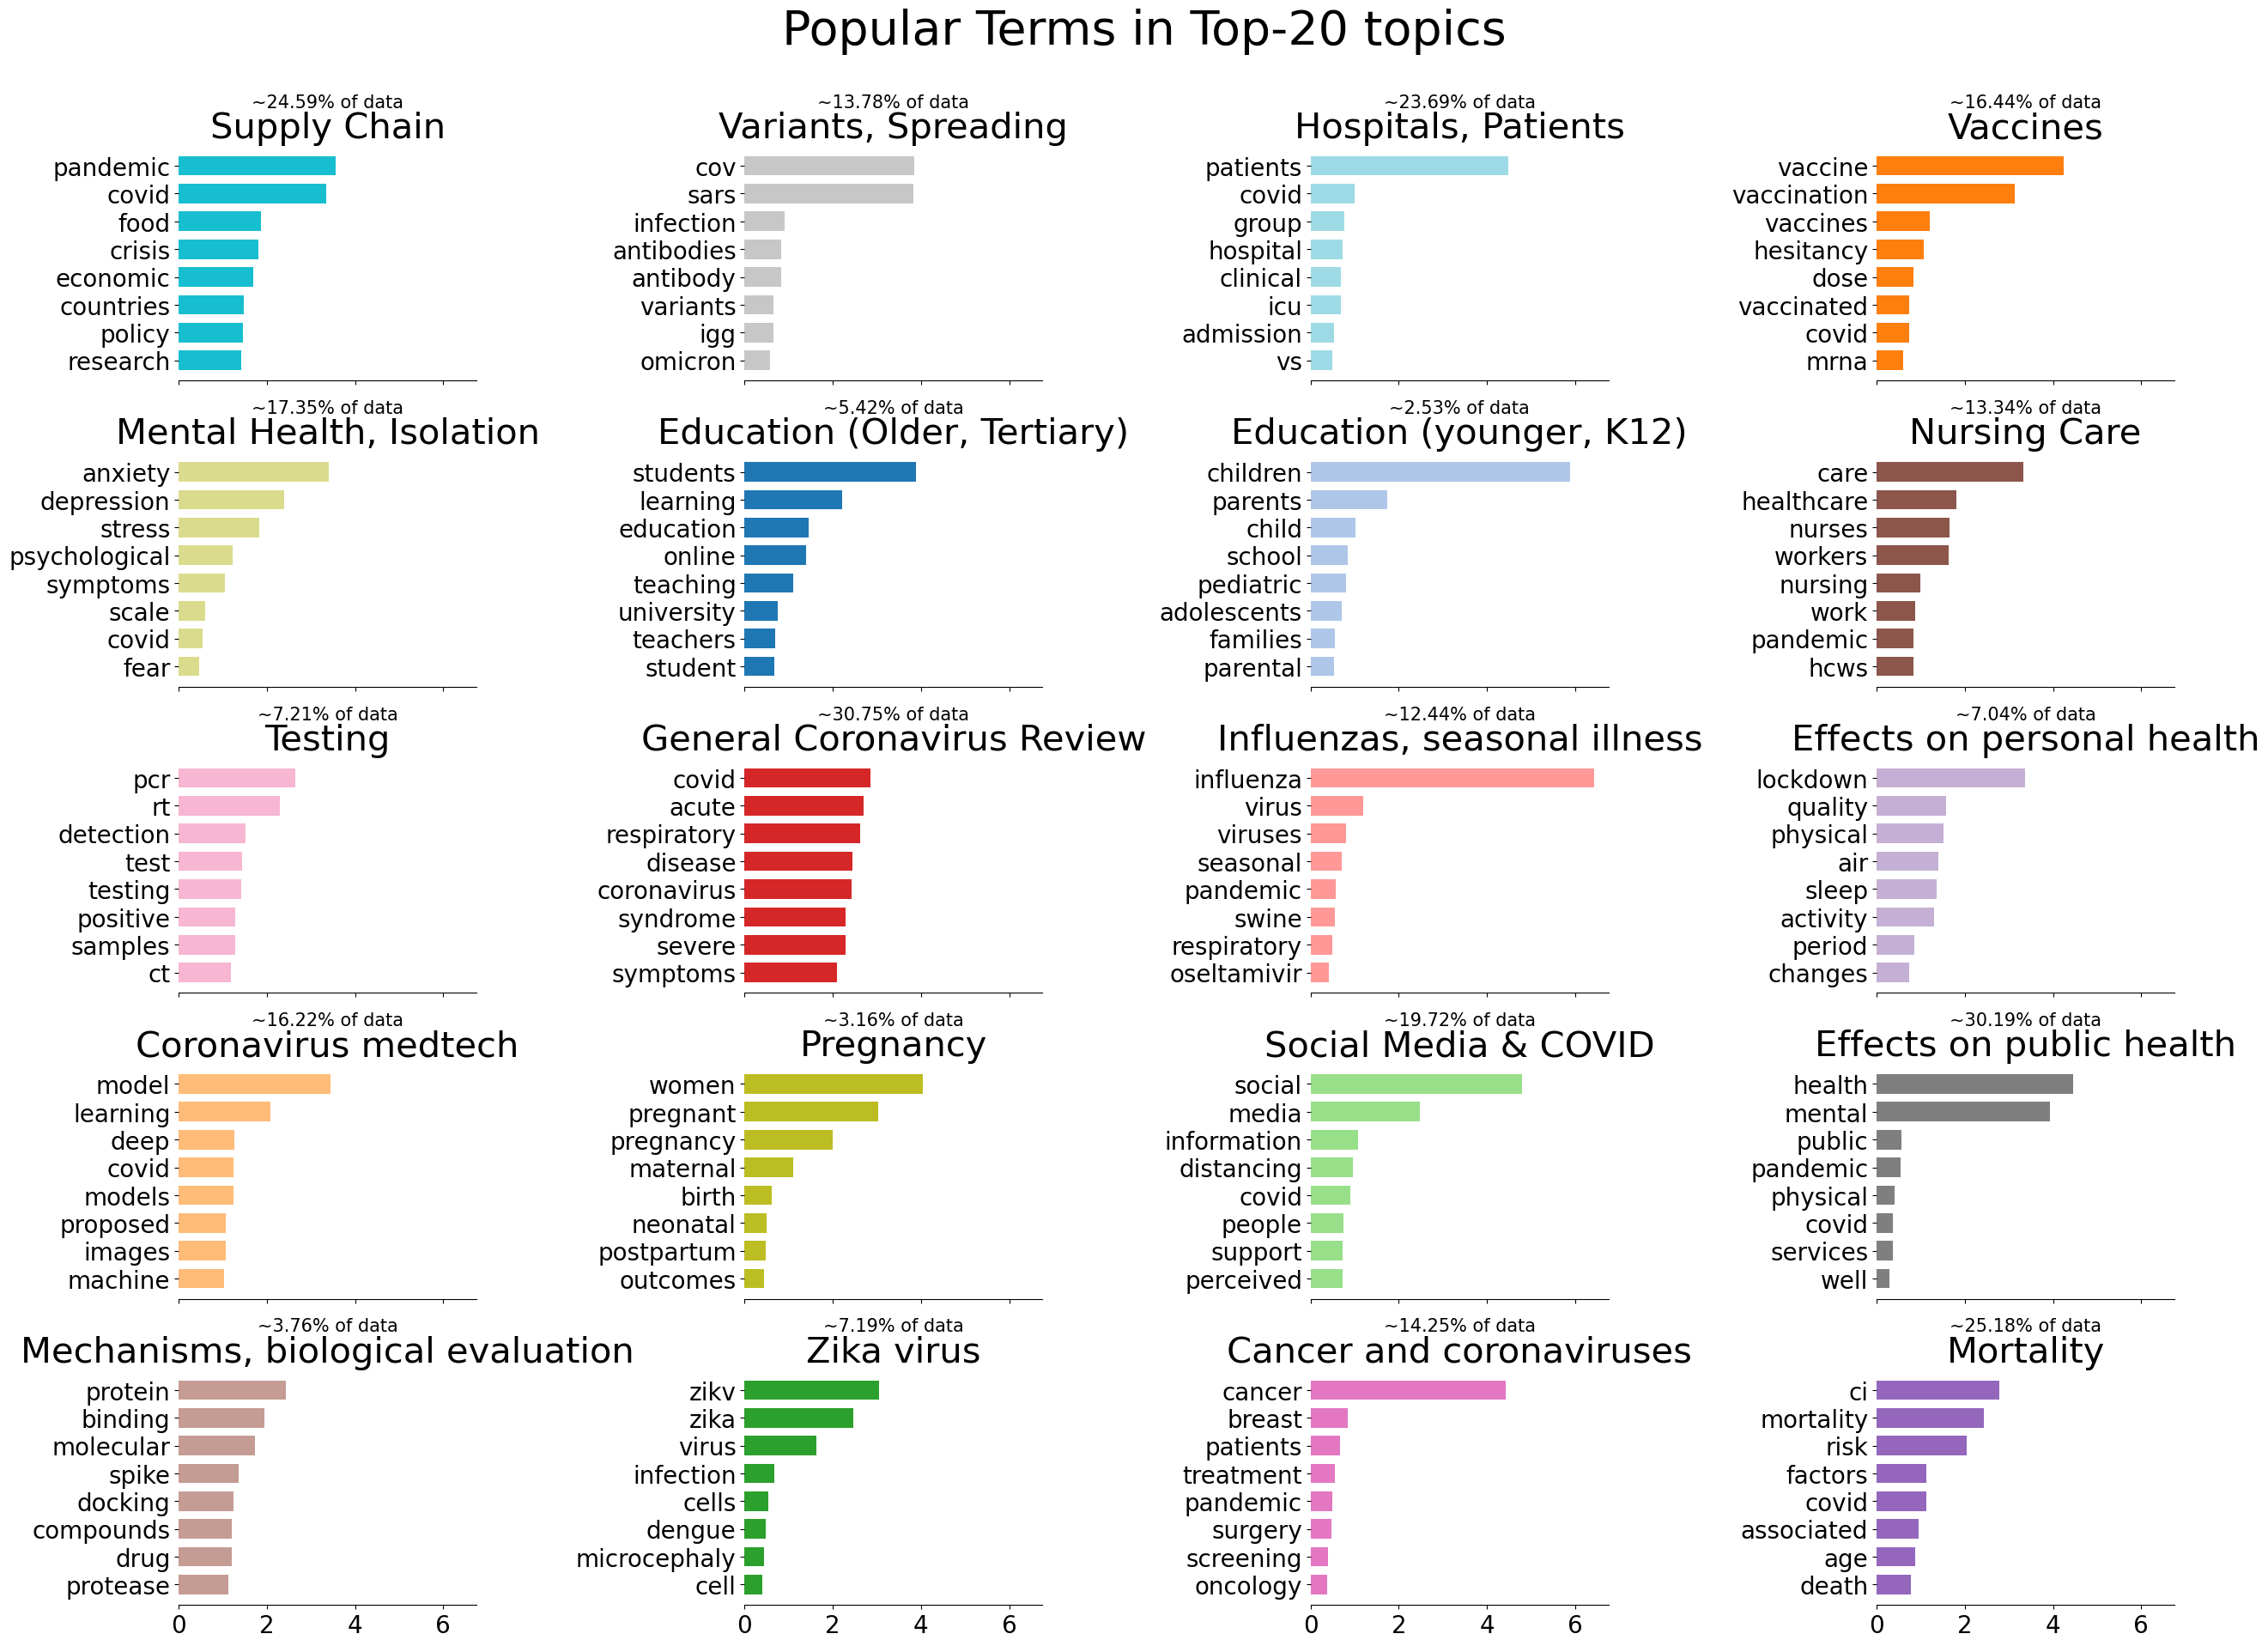

In [163]:
cols = int(NUM_TOPICS ** 0.5)
rows = NUM_TOPICS // cols

TOPIC_NAMES = ["Supply Chain", "Variants, Spreading", "Hospitals, Patients", "Vaccines",
               "Mental Health, Isolation", "Education (Older, Tertiary)", "Education (younger, K12)", "Nursing Care",
               "Testing", "General Coronavirus Review", "Influenzas, seasonal illness", "Effects on personal health",
               "Coronavirus medtech", "Pregnancy", "Social Media & COVID", "Effects on public health",
               "Mechanisms, biological evaluation", "Zika virus", "Cancer and coronaviruses", "Mortality"]

colors = plt.color_sequences["tab20"]
random.Random(321).shuffle(colors)

fig, axes = plt.subplots(rows, cols, figsize=(30, 20), sharex=True)
axes = axes.flatten()
for topic_idx, topic in enumerate(nmf.components_):
    top_features_ind = topic.argsort()[-8:]
    top_features = vectorizer.get_feature_names_out()[top_features_ind]
    weights = topic[top_features_ind]

    ax = axes[topic_idx]

    # The percentage of documents' occurances of the top words. Gives a good idea intuitively of the
    # size of the topic, but shouldn't be construed to have scientific rigor
    percentage_occupied = (term_mat[:, top_features_ind] > 0).mean() * 100
    
    ax.barh(top_features, weights, height=0.7, color=colors[topic_idx])
    ax.set_title(TOPIC_NAMES[topic_idx], fontdict={"fontsize": 30})
    ax.text(0.5, 1.22, f"~{percentage_occupied:.2f}% of data", ha="center", va="top", fontsize=15, transform=ax.transAxes)
    ax.tick_params(axis="both", which="major", labelsize=20)
    for i in "top right left".split():
        ax.spines[i].set_visible(False)
    fig.suptitle(f"Popular Terms in Top-{NUM_TOPICS} topics", fontsize=40)

plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
plt.show()

We can't perform clustering on the entire dataset -- it'd need to allocate 412G of memory for `term_mat.toarray()` because `linkage` can't work on sparse matrices. I don't have 412G of memory, even counting swap -- that is untenable, so we'll find a workaround.

Instead, let's limit the documents and terms considered to those derived in the previous cell: this will ensure that we can see the structure of our terms, but will make it less painful with allocations. 

In [196]:
clustering_term_indexes = np.zeros(8 * NUM_TOPICS)
terms = np.zeros(8 * NUM_TOPICS, dtype=object)

for topic_i, topic in enumerate(nmf.components_):
    top_features_ind = topic.argsort()[-8:]
    np.copyto(clustering_term_indexes[topic_i*8:topic_i*8+8], top_features_ind)
    np.copyto(terms[topic_i*8:topic_i*8+8], vectorizer.get_feature_names_out()[top_features_ind])

clustering_documents = term_mat[:, clustering_term_indexes]
nonzero_clustering_documents = clustering_documents[clustering_documents.getnnz(1)>0]

In [197]:
condensed_distance_mat = pdist(clustering_documents.toarray().transpose(), metric="cosine")

In [195]:
linkage_mat = linkage(condensed_distance_mat, method='ward')

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/usr/lib/python3/dist-packages/IPython/core/interactiveshell.py", line 3378, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_246838/117344342.py", line 1, in <module>
    linkage_mat = linkage(condensed_distance_mat, method='ward')
  File "/usr/lib/python3/dist-packages/scipy/cluster/hierarchy.py", line 1030, in linkage
    raise ValueError("The condensed distance matrix must contain only "
                     "finite values.")
ValueError: The condensed distance matrix must contain only finite values.

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3/dist-packages/IPython/core/interactiveshell.py", line 1997, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
        etype, value, tb, tb_offset=tb_offset
    )
  File "/usr/lib/python3/dist-packages/IPyth

Note: This doesn't consider two identical terms from different topics to be different. I'm not sure if we want to, though?

/usr/lib/python3/dist-packages/scipy/cluster/hierarchy.py:2820: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([0, dvw])


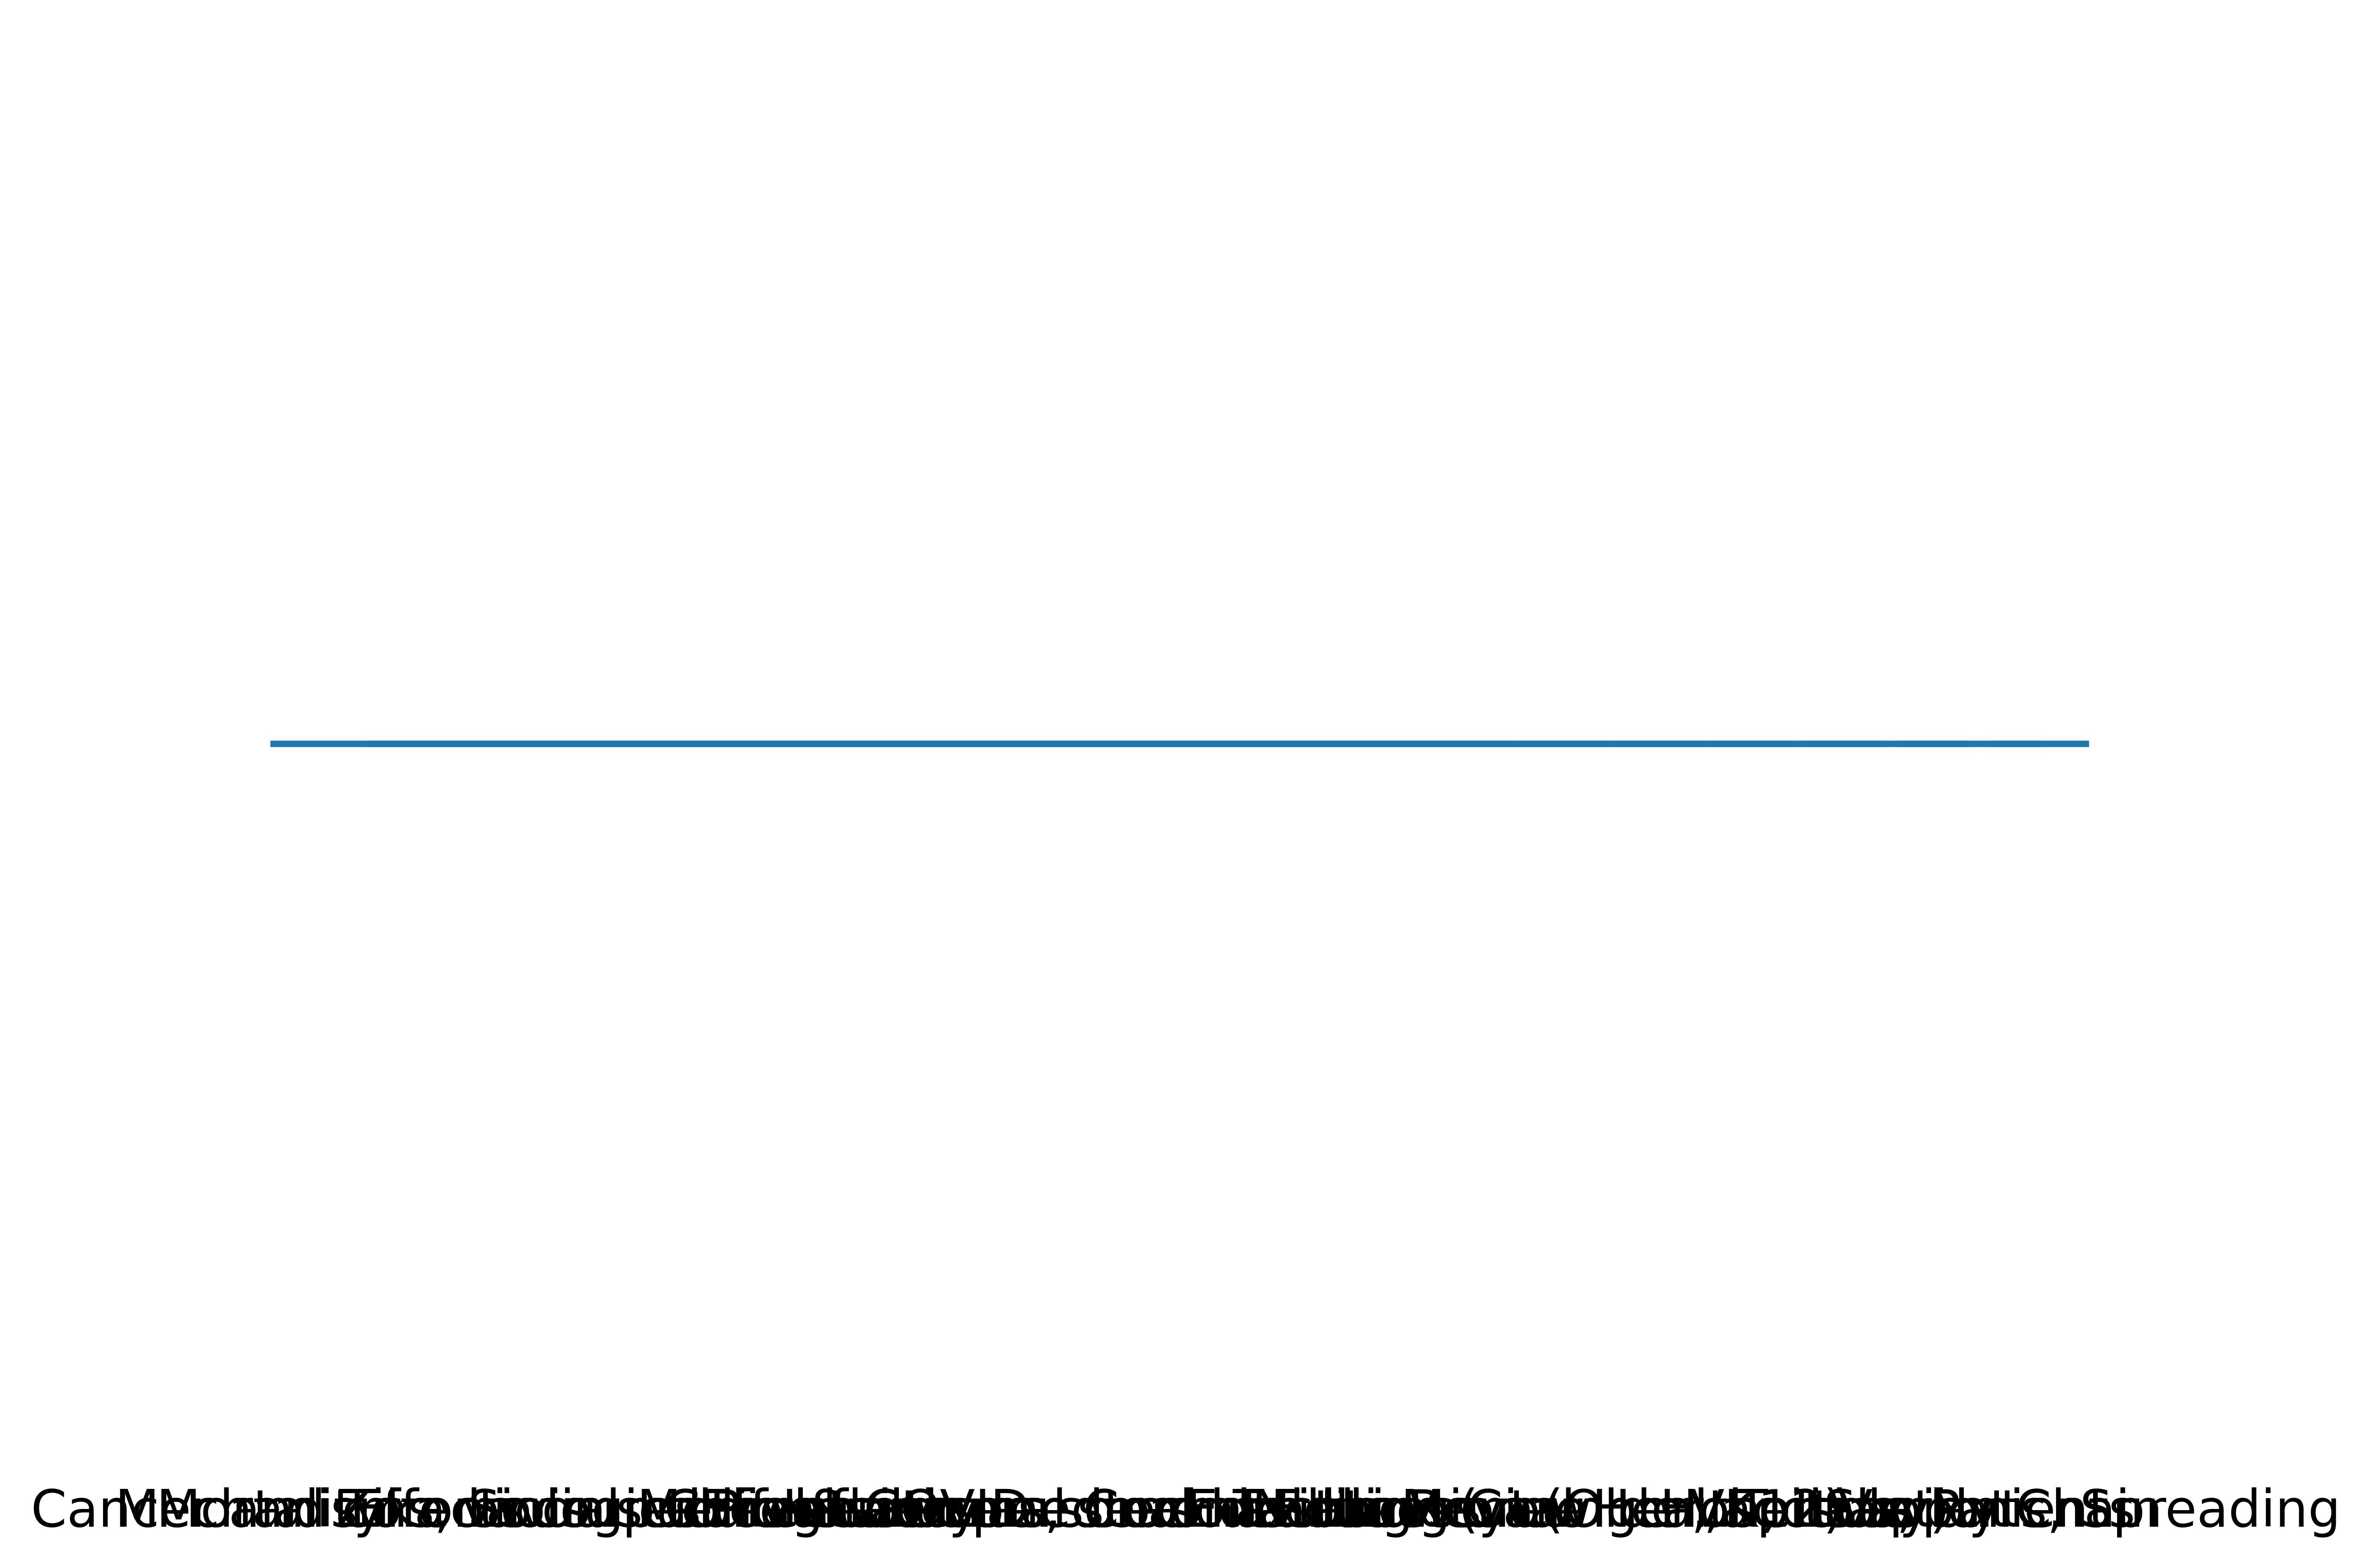

In [191]:
fig = plt.figure(figsize=(8, 6), dpi=800)
dendrogram(linkage_mat, labels=TOPIC_NAMES)
plt.yticks([])
fig.axes[0].set_frame_on(False)

([<matplotlib.patches.Wedge at 0x7f2933602490>,
 [Text(-0.16582180200751626, 1.0874295977114934, 'covid-19'),
  Text(-0.7798491946510793, -0.7757804029505148, 'sars-cov-2'),
  Text(-0.1541360896867086, -1.0891474031810804, 'pandemic'),
  Text(0.18435156331590072, -1.0844420229329845, 'coronavirus'),
  Text(0.46137123741717, -0.9985672642762476, 'covid-19 pandemic'),
  Text(0.6565361733328221, -0.8825872495711088, 'mental health'),
  Text(0.7797332342336261, -0.775896954132164, 'anxiety'),
  Text(0.8706782727670214, -0.6722494665906672, 'mortality'),
  Text(0.9461389295318804, -0.5610892317842747, 'vaccination'),
  Text(1.0054654806543175, -0.4461380584668634, 'depression'),
  Text(1.0484959696988194, -0.3326502690895237, 'public health'),
  Text(1.0762713968333832, -0.22724409862154474, 'vaccine'),
  Text(1.0923196090354297, -0.12976082504626002, 'epidemiology'),
  Text(1.099252481380261, -0.04054605010773387, 'lockdown')])

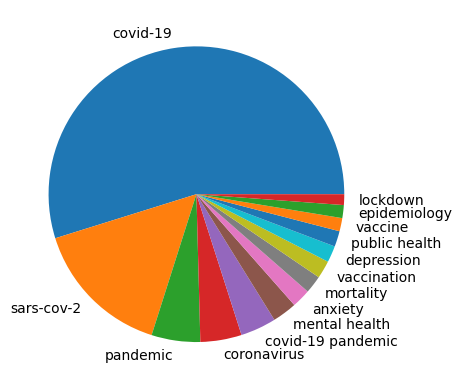

In [64]:
d = dict()
for item in df["keywords"]:
    if str(item) != 'nan':
        kws = item.split("|")
        for jtem in kws:
            jtem = jtem.lower()
            if jtem not in d:
                d[jtem] = 1
            else:
                d[jtem] += 1


l = [(item[1], item[0]) for item in d.items()]
s = sorted(l, key=lambda key: key[0])
top50 = s[-1:-15:-1]
plt.pie([item[0] for item in top50], labels=[item[1] for item in top50])

([<matplotlib.patches.Wedge at 0x7f2934895d10>,
 [Text(-0.16582180200751626, 1.0874295977114934, 'covid-19'),
  Text(-0.7798491946510793, -0.7757804029505148, 'sars-cov-2'),
  Text(-0.1541360896867086, -1.0891474031810804, 'pandemic'),
  Text(0.18435156331590072, -1.0844420229329845, 'coronavirus'),
  Text(0.46137123741717, -0.9985672642762476, 'covid-19 pandemic'),
  Text(0.6565361733328221, -0.8825872495711088, 'mental health'),
  Text(0.7797332342336261, -0.775896954132164, 'anxiety'),
  Text(0.8706782727670214, -0.6722494665906672, 'mortality'),
  Text(0.9461389295318804, -0.5610892317842747, 'vaccination'),
  Text(1.0054654806543175, -0.4461380584668634, 'depression'),
  Text(1.0484959696988194, -0.3326502690895237, 'public health'),
  Text(1.0762713968333832, -0.22724409862154474, 'vaccine'),
  Text(1.0923196090354297, -0.12976082504626002, 'epidemiology'),
  Text(1.099252481380261, -0.04054605010773387, 'lockdown')])

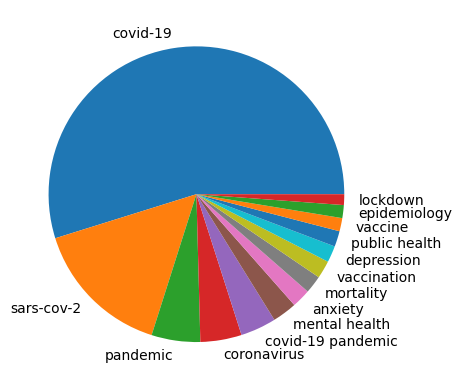